ip_prob shape: (37913, 104)
ip_real shape: (105120,)
ip_prob time range: 2022-12-01 00:00:00 -> 2023-12-30 22:00:00
ip_real time range: 2021-01-01 00:00:00 -> 2023-12-31 23:45:00
K = 8 | DT = 0 days 00:15:00 | lam = 0.995 | scenarios = 500
quantiles: [0.01 0.05 0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  0.95 0.99]
forecast_time: 2023-12-30 22:00:00
[Column check] OK — all required quantile columns exist.
X_df shape: (37905, 8) | U_df shape: (37905, 8)


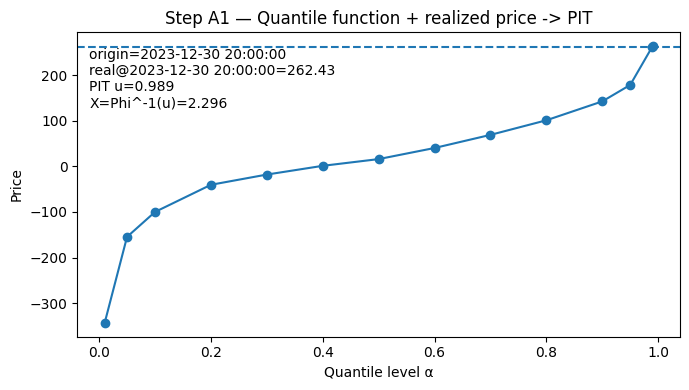

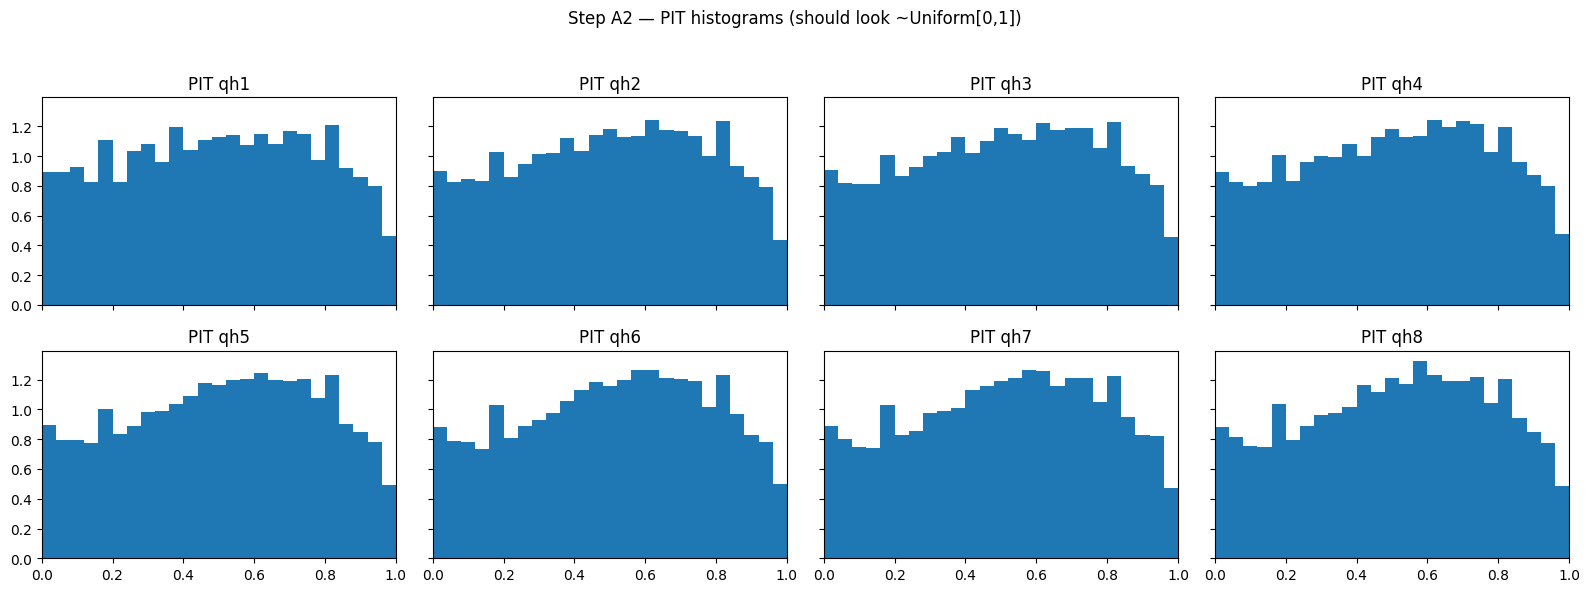

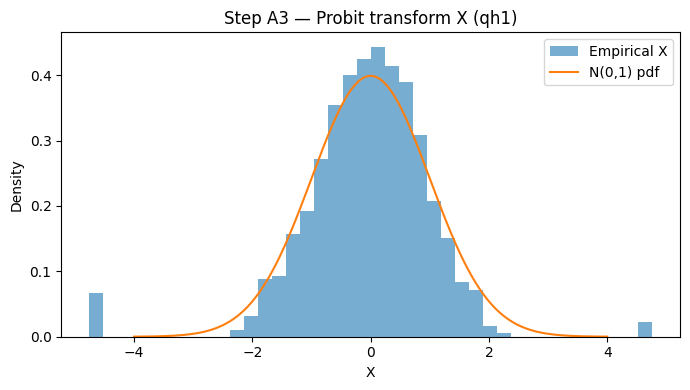

Sigma_final shape: (8, 8)


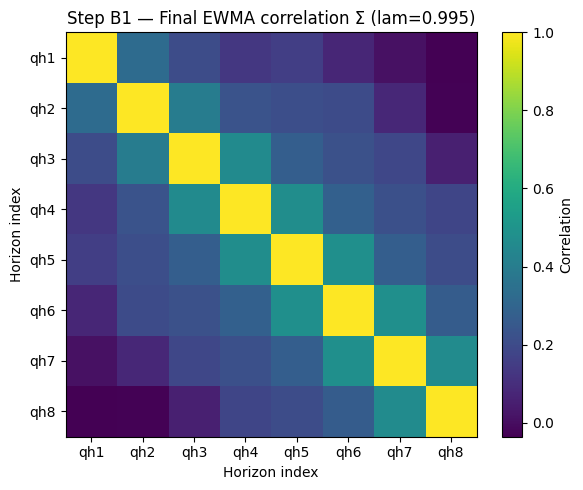

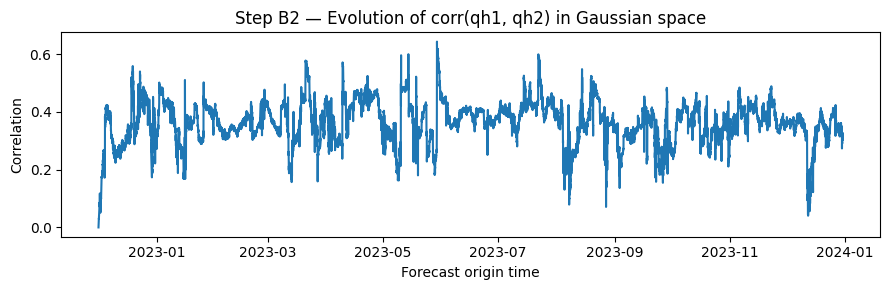

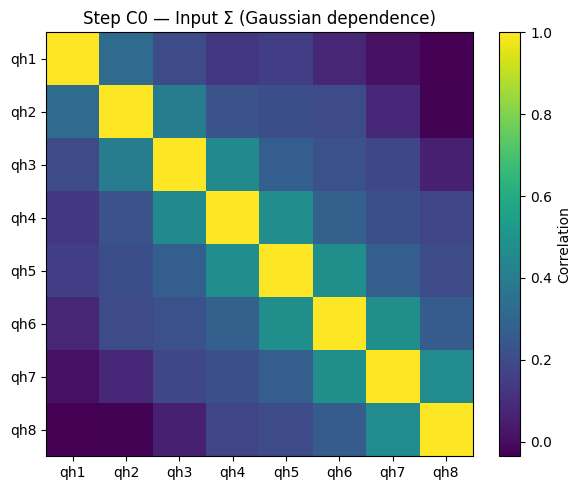

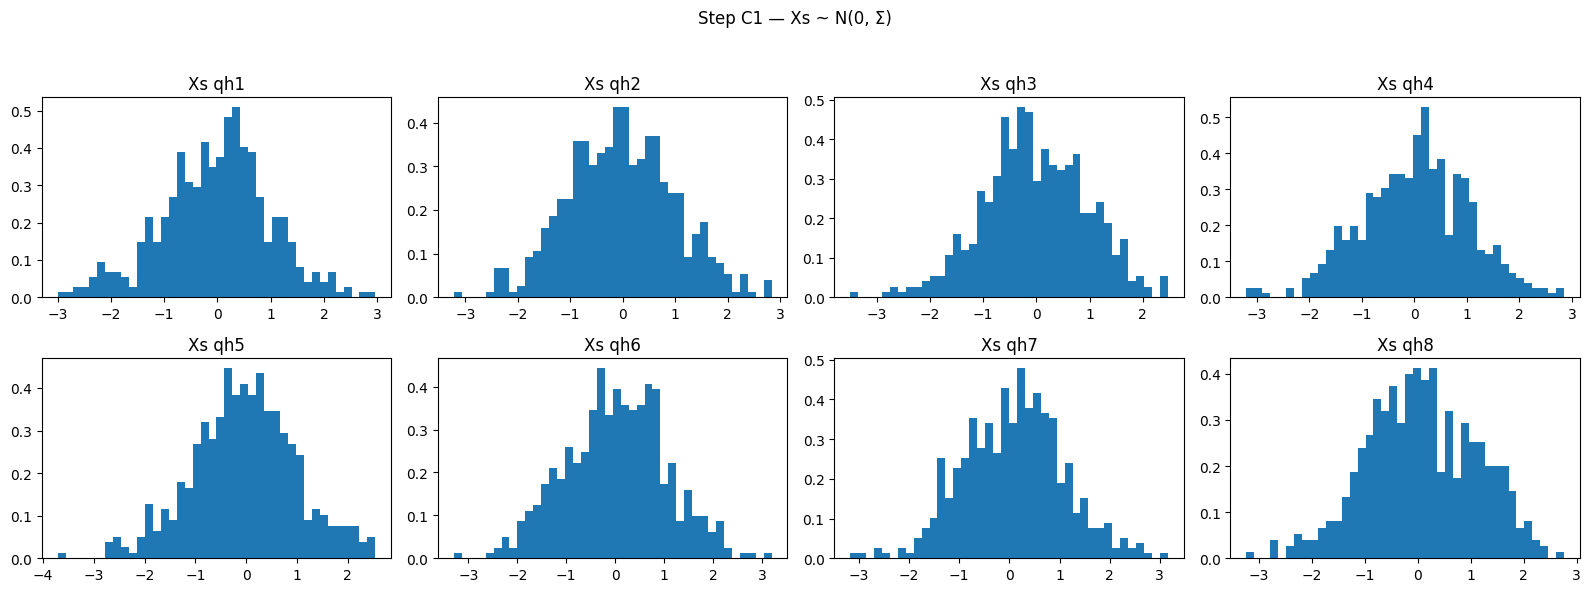

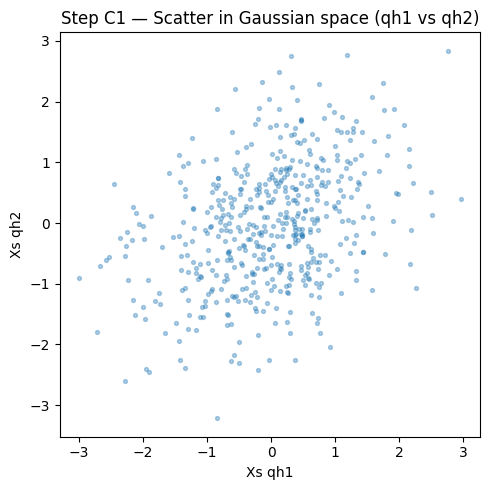

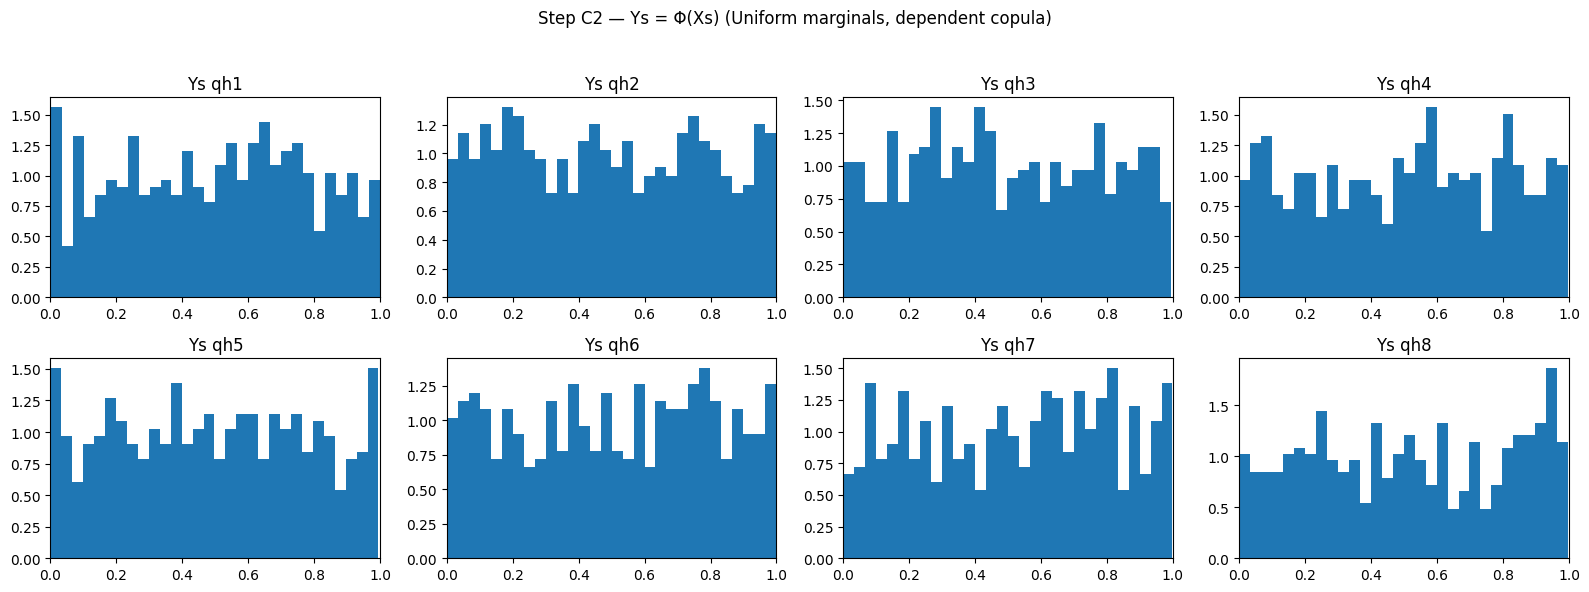

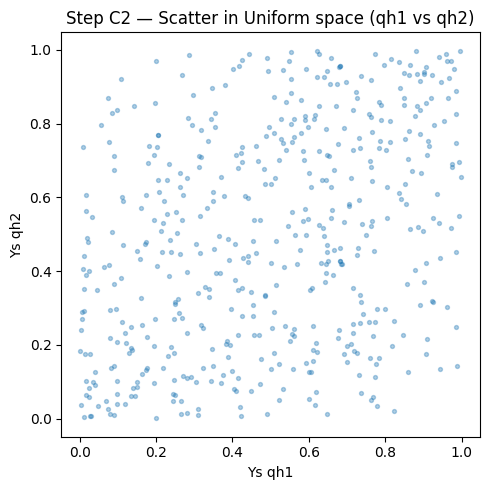

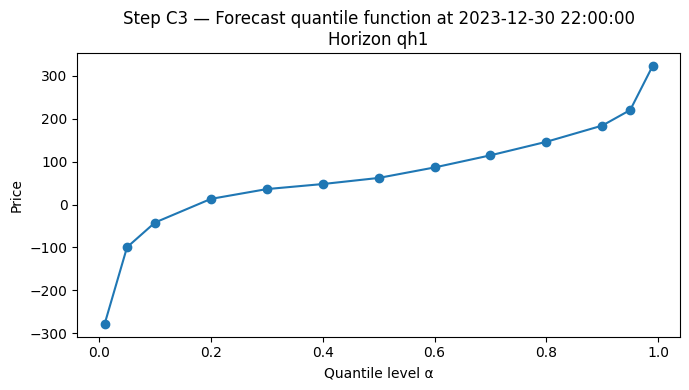

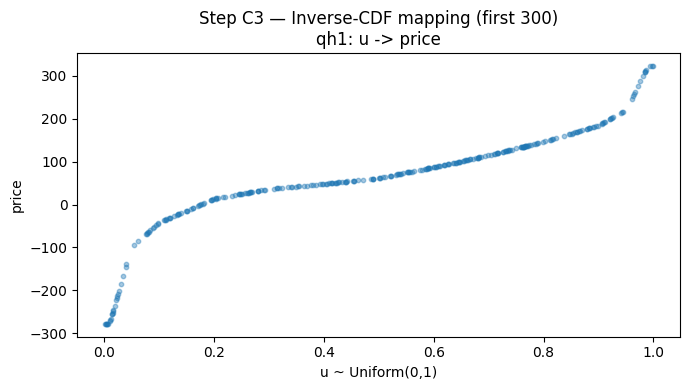

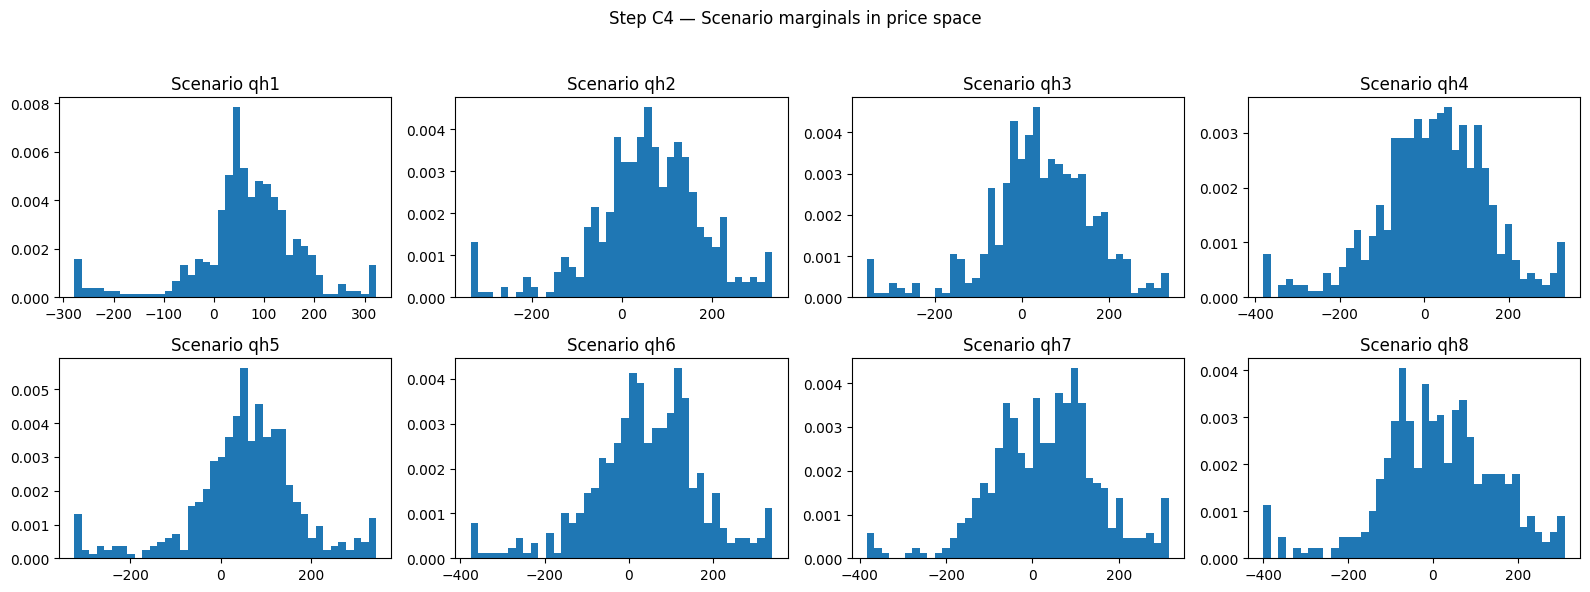

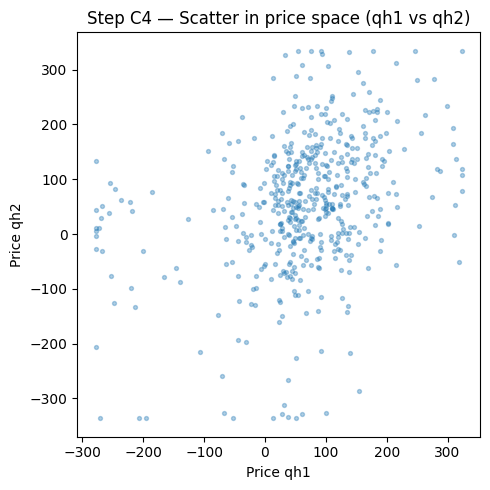

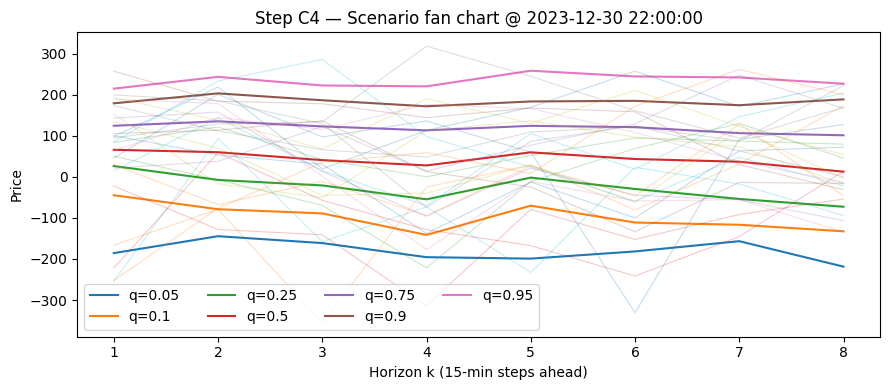

Xs: (500, 8) | Ys: (500, 8) | scenarios: (500, 8)


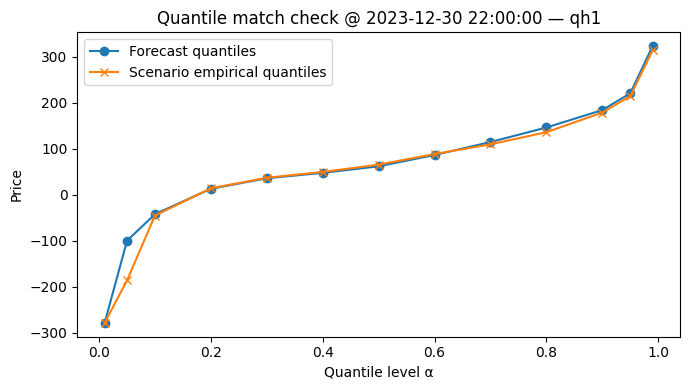

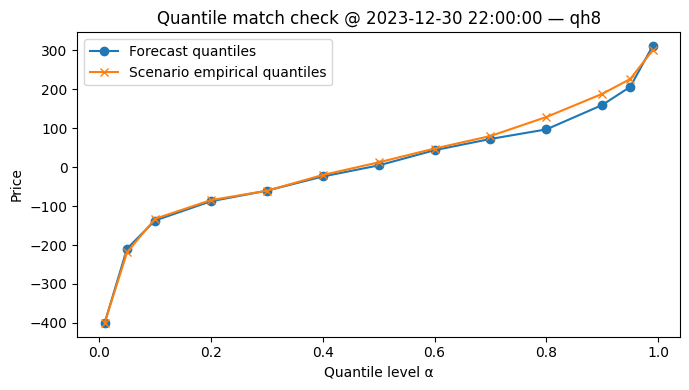

In [5]:
# ============================================================
# Copula notebook (clean version) — QR quantiles -> scenarios
# Quantiles supported: [0.01,0.05,0.10,...,0.99]
# ============================================================

# -----------------------------
# Cell 0 — Imports + project path
# -----------------------------
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Optional, Tuple


# -----------------------------
# Cell 1 — Load data
# -----------------------------
import util.read_price as read_price

ip_prob = read_price.read_ip_forecast(model="QR", kind="probabilistic", freq="15min")
ip_real = read_price.read_ip_real_prices(freq="15min", keep_extra_columns=False)["Price"]

ip_prob = ip_prob.sort_index()
ip_real = ip_real.sort_index()

print("ip_prob shape:", ip_prob.shape)
print("ip_real shape:", ip_real.shape)
print("ip_prob time range:", ip_prob.index.min(), "->", ip_prob.index.max())
print("ip_real time range:", ip_real.index.min(), "->", ip_real.index.max())


# -----------------------------
# Cell 2 — Config
# -----------------------------
DT = pd.Timedelta(minutes=15)
K = 8
lam = 0.995
n_scenarios = 500

quantiles = np.array([0.01,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,0.95,0.99], dtype=float)
quantiles = np.unique(np.sort(quantiles))
assert (quantiles > 0).all() and (quantiles < 1).all()

forecast_time = ip_prob.index[-1]  # choose any timestamp available in ip_prob

print("K =", K, "| DT =", DT, "| lam =", lam, "| scenarios =", n_scenarios)
print("quantiles:", quantiles)
print("forecast_time:", forecast_time)


# ============================================================
# Cell 3 — Column naming + checks
# ============================================================
def qcols_for_horizon(k: int, quantiles: np.ndarray) -> list:
    # Expected: qh1_q0.01 ... qh1_q0.99  (two decimals)
    return [f"qh{k}_q{q:.2f}" for q in quantiles]

def check_required_columns(ip_prob: pd.DataFrame, K: int, quantiles: np.ndarray) -> None:
    missing = []
    for k in range(1, K + 1):
        cols = qcols_for_horizon(k, quantiles)
        miss_k = [c for c in cols if c not in ip_prob.columns]
        if miss_k:
            missing.append((k, miss_k[:10], len(miss_k)))
    if missing:
        print("\n[Column check] Missing columns detected:")
        for k, sample, nmiss in missing:
            print(f"  - qh{k}: missing {nmiss} cols; first few:", sample)
        raise ValueError(
            "Your quantile column naming does not match expected 'qh{k}_q{q:.2f}'. "
            "Either rename your columns or adapt qcols_for_horizon()."
        )
    else:
        print("[Column check] OK — all required quantile columns exist.")

check_required_columns(ip_prob, K=K, quantiles=quantiles)


# ============================================================
# Cell 4 — Step A: PIT + probit X (no leakage)
# ============================================================
def enforce_monotone(values: np.ndarray) -> np.ndarray:
    # makes quantile function non-decreasing
    return np.maximum.accumulate(values)

def compute_pit_and_probit_X(
    ip_prob: pd.DataFrame,
    ip_real: pd.Series,
    *,
    K: int,
    quantiles: np.ndarray,
    as_of: Optional[pd.Timestamp] = None,
    dt: pd.Timedelta = pd.Timedelta(minutes=15),
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each forecast origin t (index of ip_prob):
      - horizon k verifies at t + (k-1)*dt
      - PIT u_{t,k} = position of realized price in quantile function
      - X_{t,k} = Phi^{-1}(u_{t,k})

    No leakage:
      Keep only origins t such that ALL verification points are strictly before as_of:
        t + (K-1)*dt < as_of  <=>  t <= as_of - K*dt
    """
    ip_prob = ip_prob.sort_index()
    ip_real = ip_real.sort_index()

    if as_of is not None:
        cutoff = pd.to_datetime(as_of) - K * dt
        ip_prob = ip_prob.loc[ip_prob.index <= cutoff]

    U_rows, X_rows, idx = [], [], []

    for t in ip_prob.index:
        u_t, x_t = [], []
        ok = True

        for k in range(1, K + 1):
            t_real = t + (k - 1) * dt
            if t_real not in ip_real.index:
                ok = False
                break

            p_real = float(ip_real.loc[t_real])

            q_vals = ip_prob.loc[t, qcols_for_horizon(k, quantiles)].astype(float).values
            q_vals = enforce_monotone(q_vals)

            # PIT: interpolate price -> quantile level
            u = np.interp(p_real, q_vals, quantiles, left=0.0, right=1.0)
            u = float(np.clip(u, 1e-6, 1 - 1e-6))
            x = float(norm.ppf(u))

            u_t.append(u)
            x_t.append(x)

        if ok:
            idx.append(t)
            U_rows.append(u_t)
            X_rows.append(x_t)

    U_df = pd.DataFrame(U_rows, index=pd.DatetimeIndex(idx), columns=[f"U_qh{k}" for k in range(1, K + 1)])
    X_df = pd.DataFrame(X_rows, index=pd.DatetimeIndex(idx), columns=[f"X_qh{k}" for k in range(1, K + 1)])
    return X_df, U_df


# Run Step A using only history strictly before forecast_time
X_df, U_df = compute_pit_and_probit_X(
    ip_prob, ip_real,
    K=K, quantiles=quantiles,
    as_of=forecast_time, dt=DT
)

print("X_df shape:", X_df.shape, "| U_df shape:", U_df.shape)
if X_df.empty:
    raise ValueError("Not enough fully-verified history before forecast_time. Pick an earlier forecast_time or reduce K.")


# -----------------------------
# Cell 5 — Step A plots
# -----------------------------
# A1) show one quantile function + realized value => PIT
t_plot = X_df.index[-1]          # last fully verified origin before forecast_time
k_show = 1
t_real = t_plot + (k_show - 1) * DT
p_real = float(ip_real.loc[t_real])

q_vals = ip_prob.loc[t_plot, qcols_for_horizon(k_show, quantiles)].astype(float).values
q_vals = enforce_monotone(q_vals)
u = np.interp(p_real, q_vals, quantiles, left=0.0, right=1.0)

plt.figure(figsize=(7, 4))
plt.plot(quantiles, q_vals, marker="o")
plt.axhline(p_real, linestyle="--")
plt.scatter([u], [p_real], zorder=5)
plt.text(
    0.02, 0.95,
    f"origin={t_plot}\nreal@{t_real}={p_real:.2f}\nPIT u={u:.3f}\nX=Phi^-1(u)={norm.ppf(np.clip(u,1e-6,1-1e-6)):.3f}",
    transform=plt.gca().transAxes, va="top"
)
plt.xlabel("Quantile level α")
plt.ylabel("Price")
plt.title("Step A1 — Quantile function + realized price -> PIT")
plt.tight_layout()
plt.show()

# A2) PIT histograms (ideal uniform)
ncols = 4
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)
axes = np.array(axes).ravel()

for k in range(1, K + 1):
    ax = axes[k - 1]
    ax.hist(U_df[f"U_qh{k}"].values, bins=25, density=True)
    ax.set_title(f"PIT qh{k}")
    ax.set_xlim(0, 1)

for j in range(K, len(axes)):
    axes[j].axis("off")

fig.suptitle("Step A2 — PIT histograms (should look ~Uniform[0,1])")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# A3) probit X distribution (should look ~N(0,1) if calibrated)
kx = 1
xvals = X_df[f"X_qh{kx}"].values

plt.figure(figsize=(7, 4))
plt.hist(xvals, bins=40, density=True, alpha=0.6, label="Empirical X")
grid = np.linspace(-4, 4, 400)
plt.plot(grid, norm.pdf(grid), label="N(0,1) pdf")
plt.title(f"Step A3 — Probit transform X (qh{kx})")
plt.xlabel("X")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Cell 6 — Step B: EWMA correlation estimation (Gaussian copula)
# ============================================================
def estimate_ewma_correlation_path(X_df: pd.DataFrame, lam: float = 0.995) -> Tuple[list, np.ndarray]:
    """
    EWMA covariance update in Gaussian space:
      Sigma <- lam*Sigma + (1-lam)*x x^T
    then normalize to correlation.
    """
    X = X_df.values
    K = X.shape[1]

    Sigma = np.eye(K)
    path = []

    for xt in X:
        xt = xt.reshape(-1, 1)
        Sigma = lam * Sigma + (1 - lam) * (xt @ xt.T)

        std = np.sqrt(np.diag(Sigma))
        Sigma = Sigma / np.outer(std, std)

        path.append(Sigma.copy())

    return path, Sigma


Sigma_path, Sigma_final = estimate_ewma_correlation_path(X_df, lam=lam)
print("Sigma_final shape:", Sigma_final.shape)


# -----------------------------
# Cell 7 — Step B plots
# -----------------------------
plt.figure(figsize=(6, 5))
plt.imshow(Sigma_final, aspect="auto")
plt.colorbar(label="Correlation")
plt.title(f"Step B1 — Final EWMA correlation Σ (lam={lam})")
plt.xlabel("Horizon index")
plt.ylabel("Horizon index")
plt.xticks(range(K), [f"qh{i}" for i in range(1, K+1)])
plt.yticks(range(K), [f"qh{i}" for i in range(1, K+1)])
plt.tight_layout()
plt.show()

# example: correlation evolution between qh1 and qh2
corr12 = [S[0, 1] for S in Sigma_path]
plt.figure(figsize=(9, 3))
plt.plot(X_df.index, corr12)
plt.title("Step B2 — Evolution of corr(qh1, qh2) in Gaussian space")
plt.xlabel("Forecast origin time")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


# ============================================================
# Cell 8 — Step C: Gaussian copula sampling -> Uniform -> inverse CDF mapping
# ============================================================
def inverse_cdf_from_quantiles_vectorized(
    u: np.ndarray,
    quantiles: np.ndarray,
    values: np.ndarray
) -> np.ndarray:
    """
    Piecewise-linear inverse CDF defined by (quantiles, values).
    We extend endpoints to [0,1] using edge values.
    """
    q_ext = np.concatenate(([0.0], quantiles, [1.0]))
    v_ext = np.concatenate(([values[0]], values, [values[-1]]))
    return np.interp(u, q_ext, v_ext)

def generate_scenarios_debug(
    *,
    forecast_time: pd.Timestamp,
    ip_prob: pd.DataFrame,
    Sigma: np.ndarray,
    K: int,
    quantiles: np.ndarray,
    n_scenarios: int = 500,
    seed: int = 123,
    pair: Tuple[int,int] = (0, 1),
    show: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)

    # C1: sample Gaussian vector with correlation Sigma
    Xs = rng.multivariate_normal(mean=np.zeros(K), cov=Sigma, size=n_scenarios)

    if show:
        plt.figure(figsize=(6, 5))
        plt.imshow(Sigma, aspect="auto")
        plt.colorbar(label="Correlation")
        plt.title("Step C0 — Input Σ (Gaussian dependence)")
        plt.xticks(range(K), [f"qh{i}" for i in range(1, K+1)])
        plt.yticks(range(K), [f"qh{i}" for i in range(1, K+1)])
        plt.tight_layout()
        plt.show()

        # hist grid for Xs
        ncols = 4
        nrows = int(np.ceil(K / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
        axes = np.array(axes).ravel()
        for k in range(K):
            axes[k].hist(Xs[:, k], bins=40, density=True)
            axes[k].set_title(f"Xs qh{k+1}")
        for j in range(K, len(axes)):
            axes[j].axis("off")
        fig.suptitle("Step C1 — Xs ~ N(0, Σ)")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        i, j = pair
        plt.figure(figsize=(5, 5))
        plt.scatter(Xs[:, i], Xs[:, j], s=8, alpha=0.35)
        plt.title(f"Step C1 — Scatter in Gaussian space (qh{i+1} vs qh{j+1})")
        plt.xlabel(f"Xs qh{i+1}")
        plt.ylabel(f"Xs qh{j+1}")
        plt.tight_layout()
        plt.show()

    # C2: transform to uniform marginals
    Ys = norm.cdf(Xs)

    if show:
        # hist grid for Ys
        ncols = 4
        nrows = int(np.ceil(K / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
        axes = np.array(axes).ravel()
        for k in range(K):
            axes[k].hist(Ys[:, k], bins=30, density=True)
            axes[k].set_title(f"Ys qh{k+1}")
            axes[k].set_xlim(0, 1)
        for j in range(K, len(axes)):
            axes[j].axis("off")
        fig.suptitle("Step C2 — Ys = Φ(Xs) (Uniform marginals, dependent copula)")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        i, j = pair
        plt.figure(figsize=(5, 5))
        plt.scatter(Ys[:, i], Ys[:, j], s=8, alpha=0.35)
        plt.title(f"Step C2 — Scatter in Uniform space (qh{i+1} vs qh{j+1})")
        plt.xlabel(f"Ys qh{i+1}")
        plt.ylabel(f"Ys qh{j+1}")
        plt.tight_layout()
        plt.show()

    # C3: map uniform draws through inverse CDF defined by forecast quantiles
    scenarios = np.zeros((n_scenarios, K), dtype=float)

    # show quantile function for one horizon
    if show:
        k_show = pair[0] + 1
        q_vals_show = ip_prob.loc[forecast_time, qcols_for_horizon(k_show, quantiles)].astype(float).values
        q_vals_show = enforce_monotone(q_vals_show)

        plt.figure(figsize=(7, 4))
        plt.plot(quantiles, q_vals_show, marker="o")
        plt.title(f"Step C3 — Forecast quantile function at {forecast_time}\nHorizon qh{k_show}")
        plt.xlabel("Quantile level α")
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()

        mapped = inverse_cdf_from_quantiles_vectorized(Ys[:, k_show - 1], quantiles, q_vals_show)
        plt.figure(figsize=(7, 4))
        plt.scatter(Ys[:300, k_show - 1], mapped[:300], s=10, alpha=0.4)
        plt.title(f"Step C3 — Inverse-CDF mapping (first 300)\nqh{k_show}: u -> price")
        plt.xlabel("u ~ Uniform(0,1)")
        plt.ylabel("price")
        plt.tight_layout()
        plt.show()

    # vectorized mapping per horizon
    for k in range(1, K + 1):
        q_vals = ip_prob.loc[forecast_time, qcols_for_horizon(k, quantiles)].astype(float).values
        q_vals = enforce_monotone(q_vals)
        scenarios[:, k - 1] = inverse_cdf_from_quantiles_vectorized(Ys[:, k - 1], quantiles, q_vals)

    if show:
        # distributions + fan chart
        ncols = 4
        nrows = int(np.ceil(K / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
        axes = np.array(axes).ravel()
        for k in range(K):
            axes[k].hist(scenarios[:, k], bins=40, density=True)
            axes[k].set_title(f"Scenario qh{k+1}")
        for j in range(K, len(axes)):
            axes[j].axis("off")
        fig.suptitle("Step C4 — Scenario marginals in price space")
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

        i, j = pair
        plt.figure(figsize=(5, 5))
        plt.scatter(scenarios[:, i], scenarios[:, j], s=8, alpha=0.35)
        plt.title(f"Step C4 — Scatter in price space (qh{i+1} vs qh{j+1})")
        plt.xlabel(f"Price qh{i+1}")
        plt.ylabel(f"Price qh{j+1}")
        plt.tight_layout()
        plt.show()

        horizons = np.arange(1, K + 1)
        plt.figure(figsize=(9, 4))
        for a in [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]:
            plt.plot(horizons, np.quantile(scenarios, a, axis=0), label=f"q={a}")
        for i in range(min(25, n_scenarios)):
            plt.plot(horizons, scenarios[i], linewidth=0.8, alpha=0.25)
        plt.title(f"Step C4 — Scenario fan chart @ {forecast_time}")
        plt.xlabel("Horizon k (15-min steps ahead)")
        plt.ylabel("Price")
        plt.legend(ncol=4)
        plt.tight_layout()
        plt.show()

    return Xs, Ys, scenarios


# ============================================================
# Cell 9 — Run Step C (debug)
# ============================================================
Xs, Ys, scenarios = generate_scenarios_debug(
    forecast_time=forecast_time,
    ip_prob=ip_prob,
    Sigma=Sigma_final,
    K=K,
    quantiles=quantiles,
    n_scenarios=n_scenarios,
    seed=123,
    pair=(0, 1),
    show=True
)

print("Xs:", Xs.shape, "| Ys:", Ys.shape, "| scenarios:", scenarios.shape)


# ============================================================
# Cell 10 — Quick validation: do generated scenario quantiles match forecast quantiles?
# ============================================================
def plot_quantile_match(ip_prob, scenarios, *, forecast_time, k=1, quantiles=quantiles):
    q_fore = ip_prob.loc[forecast_time, qcols_for_horizon(k, quantiles)].astype(float).values
    q_fore = enforce_monotone(q_fore)

    q_scen = np.quantile(scenarios[:, k-1], quantiles)

    plt.figure(figsize=(7, 4))
    plt.plot(quantiles, q_fore, marker="o", label="Forecast quantiles")
    plt.plot(quantiles, q_scen, marker="x", label="Scenario empirical quantiles")
    plt.title(f"Quantile match check @ {forecast_time} — qh{k}")
    plt.xlabel("Quantile level α")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_quantile_match(ip_prob, scenarios, forecast_time=forecast_time, k=1, quantiles=quantiles)
plot_quantile_match(ip_prob, scenarios, forecast_time=forecast_time, k=8, quantiles=quantiles)
        